In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch

import cv2

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset, GameDataset

from PIL import Image

import importlib
import ChessLens
importlib.reload(ChessLens);

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ds = ChessDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
# ds = GameDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
# img, y = ds[500]
# img, y = ds[340]
# img, y = ds[278]
# img, y = ds[57]

# img = ChessLens.ChessLensImage('/mnt/D/University/Thesis_Dataset/Temp/test.jpg', "cnn")
img = ChessLens.ChessLensImage('/mnt/D/University/Thesis_Dataset/Temp/photos2/photos/img_0.jpg', "cnn_onnx_static")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Temp/photo_84.jpg", "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Temp/video_2/video_14/testpic_88.jpg", "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Dataset/Images/image_137.png", "cnn")
# img = ChessLens.ChessLensImage(img, "cnn")
# y["image_path"]

In [8]:
quad, conf = img.detect_board()
# img.recognize_clock()
# img.board_detection = torch.tensor([
#     [249,484],
#     [381,481],
#     [437,631],
#     [200,639],
# ])
img.recognize_pieces()
img.save_fen_image()

In [9]:
img.board_detection

tensor([[143.7857, 107.7583],
        [464.0422, 116.7963],
        [570.0717, 418.0672],
        [ 13.8521, 407.8965]])

'RP4pr/NP4pn/BP4pb/QP4pq/KP4pk/BP4pb/NP4pn/RP4pr'

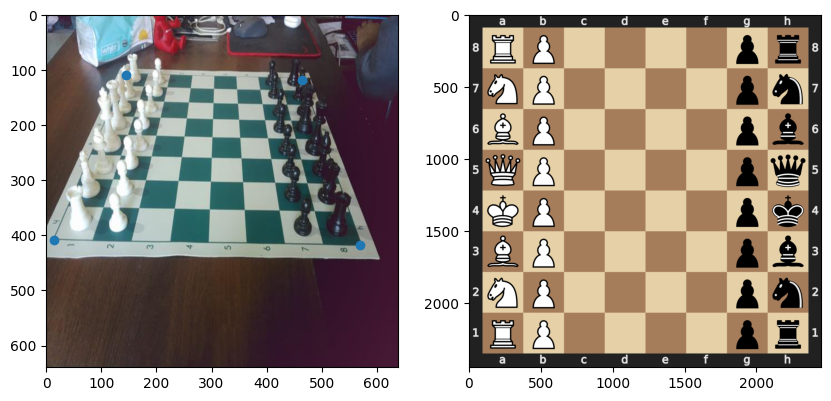

In [10]:
plt.figure(figsize=(10, 10))

plt.subplot(1,2,1)
plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
plt.subplot(1,2,2)
plt.imshow(plt.imread("out_fen.png"));
img.fen

array([[     1.0383,     0.44949,     -197.73],
       [  -0.055073,      1.9515,     -202.37],
       [-0.00013482,   0.0032307,           1]])

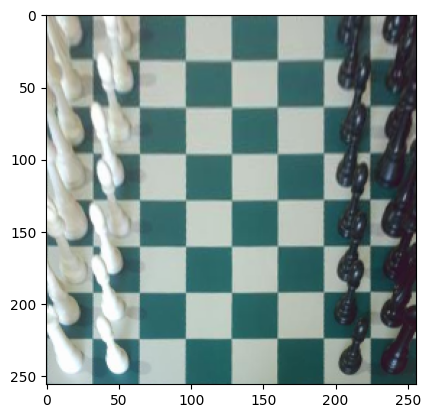

In [11]:
warpped_img, M = img.warp()
plt.imshow(warpped_img);
Image.fromarray(warpped_img).save("occlusion_test.jpg")
M